In [37]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [38]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [39]:
ticker = "^GSPC"
start_interval = "2011-12-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = torch.tensor(yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy())

In [40]:
len(raw_snp500)

3541

In [41]:
raw_snp500[0:10]

tensor([1244.5800, 1244.2800, 1257.0800, 1258.4700, 1261.0100, 1234.3500,
        1255.1899, 1236.4700, 1225.7300, 1211.8199], dtype=torch.float64)

In [42]:
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 512

train_data = Returns(
  raw_returns=train_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=val_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=test_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)

len(train_data), len(val_data), len(test_data)

(1611, 197, 197)

In [43]:
train_data[100]

tensor([[ 1.9256e-01, -4.1186e-01,  5.0242e-01, -2.7843e-01, -7.7603e-01,
         -1.5999e+00, -5.0816e-03, -4.4991e-01, -6.8362e-01,  2.0243e-01,
         -3.6410e-01, -1.1104e+00, -5.9132e-01, -4.6197e-01, -1.4931e+00,
         -7.4983e-01,  1.4870e+00,  7.9345e-03,  1.2360e-01,  9.3563e-02,
         -2.4661e-01,  1.0180e+00, -1.4234e+00, -2.5728e-01, -2.4316e+00,
         -2.8193e-02,  5.0895e-01,  2.1467e+00, -4.8908e-02,  7.3633e-01,
         -1.2567e+00,  1.0722e+00, -7.1462e-01,  9.9288e-01,  9.4763e-01,
          9.9751e-02,  8.9806e-01, -2.0056e-01, -2.1978e+00,  6.4691e-01,
         -1.5811e+00,  4.1792e-01,  8.1913e-01, -2.4125e-01,  2.3219e+00,
          1.9686e-01,  5.5712e-01, -4.8925e-01, -9.4761e-01, -1.9599e-01,
         -8.2117e-01, -4.0128e-02, -5.1817e-01,  1.5305e+00, -2.6090e-01,
          6.6929e-01,  5.9984e-01,  2.2153e-01, -1.0085e+00, -8.9692e-01,
         -9.0969e-01, -6.8805e-02,  1.5346e+00,  1.7739e+00, -8.5062e-02,
         -4.5359e-01, -3.1722e-01, -7.

In [44]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 512])

In [45]:
len(train_dataloader.dataset)

1611

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [47]:
betas = torch.linspace(1e-4, 2e-2, 1000)
type(1 - betas)

torch.Tensor

In [48]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [49]:
dir = Path().resolve().parents[1]
save_path = dir / "models"


In [50]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_512.pth",
  verbose=True
)

In [ ]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=scheduler,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:05<08:37,  5.22s/it]

Epoch : 0 | train_loss : 1.07 | val_loss : 0.96
New best model found. Current loss: 0.9621718029181162
Current LR:  [0.001]


  2%|▏         | 2/100 [00:10<08:34,  5.25s/it]

Epoch : 1 | train_loss : 0.88 | val_loss : 0.77
New best model found. Current loss: 0.7712486883004507
Current LR:  [0.001]


  3%|▎         | 3/100 [00:18<10:52,  6.73s/it]

...

Epoch : 12 | train_loss : 0.51 | val_loss : 0.61
Current LR:  [0.00016]


 14%|█▍        | 14/100 [01:04<05:58,  4.16s/it]

Epoch : 13 | train_loss : 0.50 | val_loss : 0.55
Current LR:  [6.400000000000001e-05]


 14%|█▍        | 14/100 [01:08<07:03,  4.92s/it]

Epoch : 14 | train_loss : 0.53 | val_loss : 0.56
Stopping early as no improvement has been observed
Best Loss 0.5299400836229324
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 14
Total training time: 68.92424535751343 seconds


In [52]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.6175808807214102

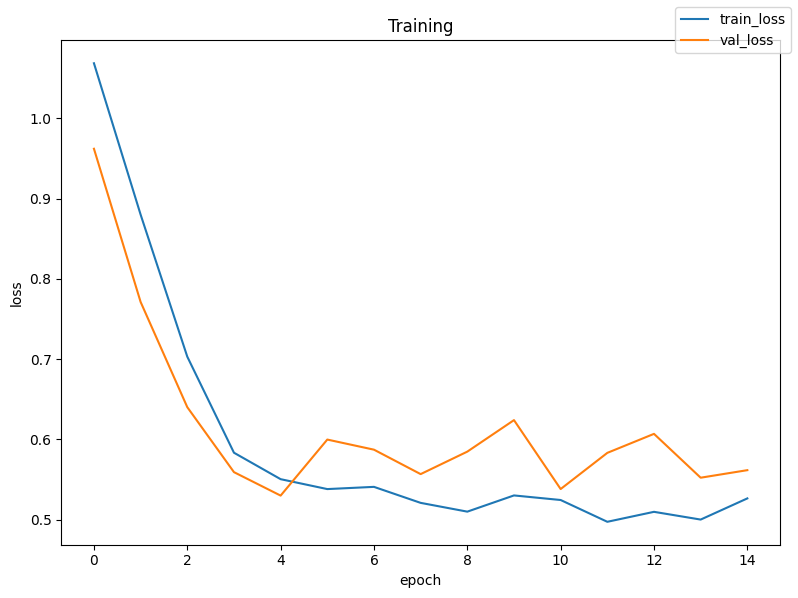

In [53]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()